In [2]:
import pandas as pd

import numpy as np 

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, classification_report, jaccard_score, log_loss

In [3]:
my_data = pd.read_csv('drug_tree.csv')

df = my_data.copy()

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,35,F,NORMAL,NORMAL,12.45,drugX
1,62,M,HIGH,HIGH,18.73,drugY
2,28,F,NORMAL,HIGH,8.21,drugC
3,44,M,LOW,NORMAL,7.63,drugA
4,51,F,HIGH,HIGH,22.14,drugY


In [4]:
df = df[ df['Sex'] != 'Sex' ]

x = df.drop('Drug', axis = 1)

y = df[['Drug']]

In [5]:
le_sex = LabelEncoder()

le_sex.fit(['F', 'M'])
x['Sex'] = le_sex.transform(x['Sex'])

le_bp = LabelEncoder()

le_bp.fit(['NORMAL', 'HIGH', 'LOW'])  

x['BP'] = le_bp.transform(x['BP'])
x['Cholesterol'] = le_bp.transform(x['Cholesterol'])

In [6]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.2, random_state = 7)

In [7]:
drugTree = DecisionTreeClassifier(criterion = "entropy", max_depth = 4)
#criterion: gini
#criterion: entropy
drugTree.fit(train_x, train_y)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = drugTree.predict(test_x)
y_pred_prob = drugTree.predict_proba(test_x)

Accuracy:  0.9824561403508771

Jaccard:  0.9655172413793104
log_loss:  0.632344796300301


              precision    recall  f1-score   support

       drugA       1.00      0.88      0.93         8
       drugB       1.00      1.00      1.00         6
       drugC       0.89      1.00      0.94         8
       drugX       1.00      1.00      1.00        10
       drugY       1.00      1.00      1.00        25

    accuracy                           0.98        57
   macro avg       0.98      0.97      0.97        57
weighted avg       0.98      0.98      0.98        57





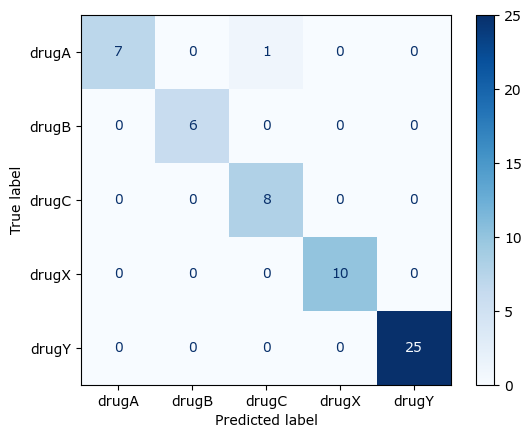

In [9]:
print("Accuracy: ", accuracy_score(test_y, y_pred))
print()
print("Jaccard: ", jaccard_score(test_y, y_pred, average = 'micro'))
print("log_loss: ", log_loss(test_y, y_pred_prob))
print()
print()

print(classification_report(test_y, y_pred))
print()
print()

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(drugTree, test_x, test_y, display_labels = drugTree.classes_, cmap = plt.cm.Blues)
plt.show()

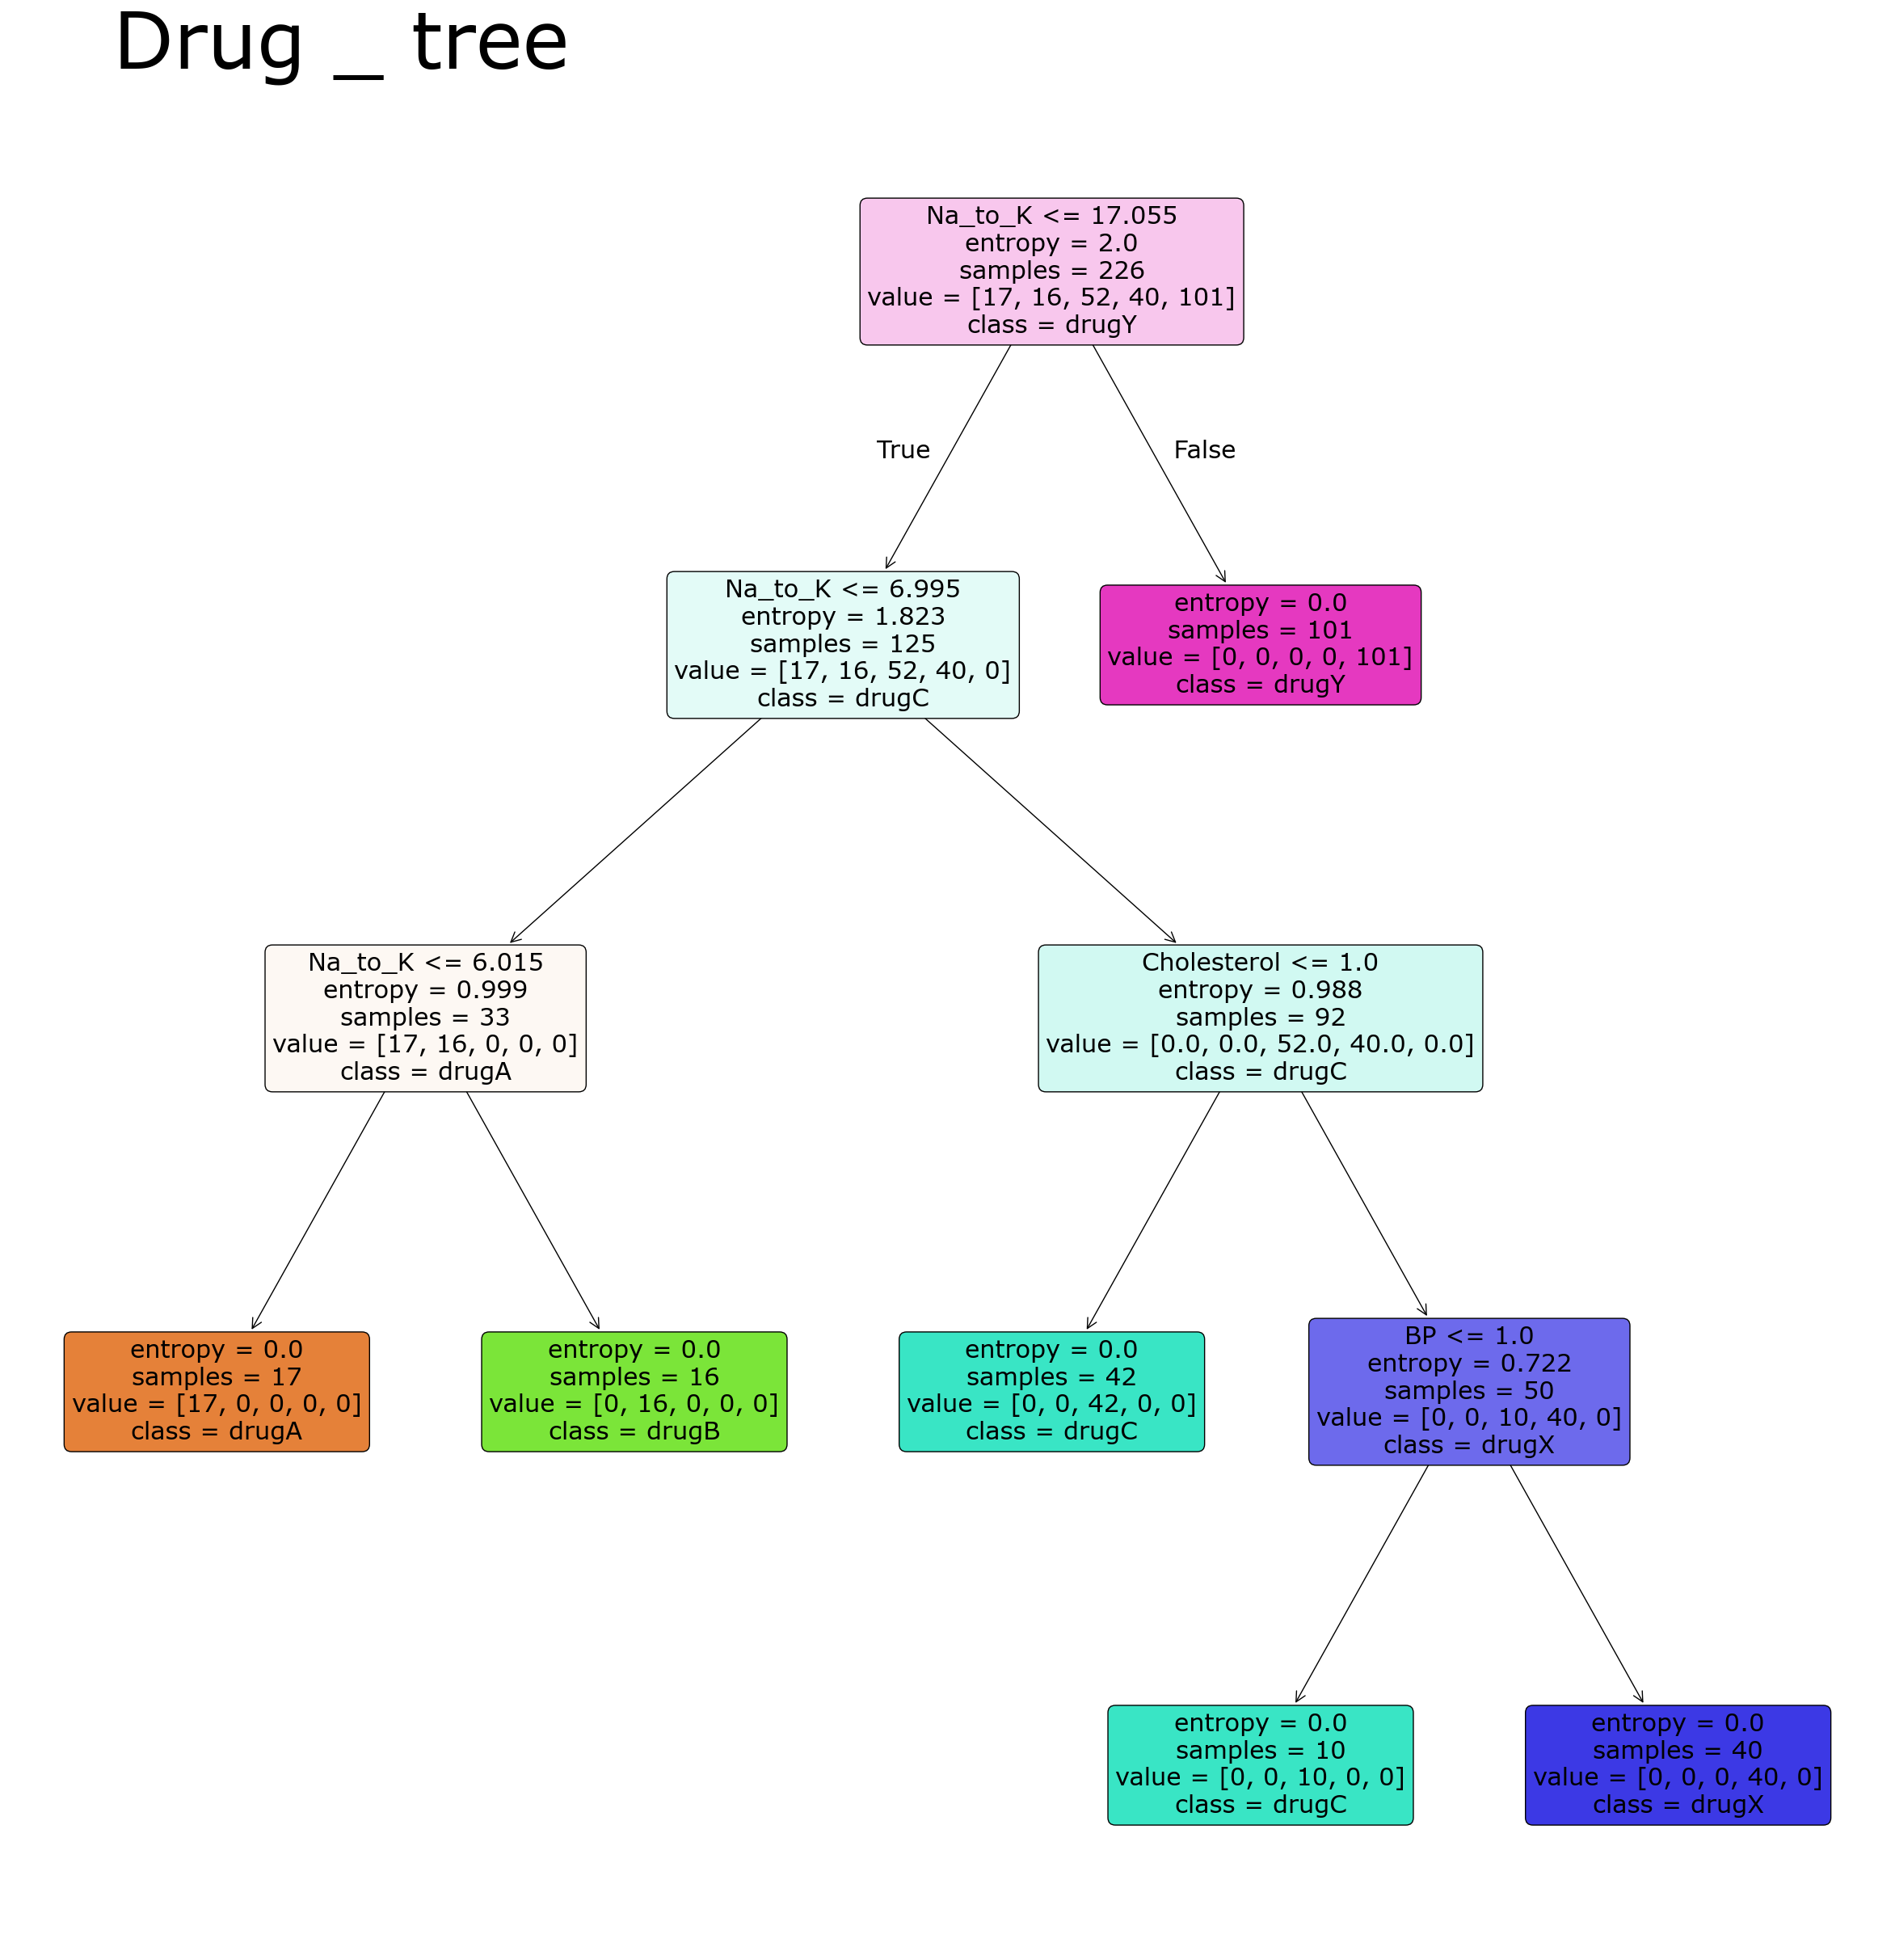

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure( figsize=(30, 30) )

plot_tree(
    
    drugTree, 
    feature_names = x.columns[0:5], 
    class_names = drugTree.classes_,
    filled=True,
    rounded=True,
    fontsize=22
    
         )         


print()
print()

plt.title("Drug _ tree                                            ", fontsize=70)
plt.show()